In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install opencv-python seaborn

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [ ]:
dataset_path = "/content/drive/MyDrive/dataset/Dataset_BUSI_with_GT"

In [ ]:
classes = ["benign","malignant","normal"]

images = []
labels = []

img_size = 224

for label, category in enumerate(classes):

    folder = os.path.join(dataset_path, category)

    for file in os.listdir(folder):

        if "_mask" in file:
            continue

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)
        img = cv2.resize(img,(img_size,img_size))
        img = img/255.0

        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Total images:",len(X))

Total images: 781


In [ ]:
y = to_categorical(y,3)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,y,test_size=0.30,random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,y_temp,test_size=0.50,random_state=42
)

print("Train:",len(X_train))
print("Validation:",len(X_val))
print("Test:",len(X_test))

Train: 546
Validation: 117
Test: 118


In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = Flatten()(x)

x = Dense(256,activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(3,activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

# best_ckpt = ModelCheckpoint(
#     "/content/drive/MyDrive/vgg16_best.h5",
#     monitor="val_accuracy",
#     save_best_only=True,
#     mode="max",
#     verbose=1
# )

# backup_ckpt = ModelCheckpoint(
#     "/content/drive/MyDrive/vgg16_backup.keras",
#     save_best_only=False
# )

# logger = CSVLogger("/content/drive/MyDrive/vgg16_log.csv", append=True)

# history = model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val,y_val),
#     epochs=50,
#     batch_size=16,
#     callbacks=[best_ckpt, backup_ckpt, logger]
# )

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.4546 - loss: 3.5437
Epoch 1: val_accuracy improved from None to 0.70940, saving model to /content/drive/MyDrive/vgg16_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 399ms/step - accuracy: 0.4817 - loss: 2.4673 - val_accuracy: 0.7094 - val_loss: 0.7396
Epoch 2/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6546 - loss: 0.7623
Epoch 2: val_accuracy improved from 0.70940 to 0.75214, saving model to /content/drive/MyDrive/vgg16_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.6685 - loss: 0.7395 - val_accuracy: 0.7521 - val_loss: 0.6691
Epoch 3/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7013 - loss: 0.7286
Epoch 3: val_accuracy did not improve from 0.75214
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.7088 - loss: 0.6896 - val_accuracy: 0.6923 - val_loss: 0.7029
Epoch 4/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7219 - loss: 0.6407
Epoch 4: val_accuracy improved from 0.75214 to 0.76068, saving model to /content/drive/MyDrive/vgg16_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.7216 - loss: 0.6530 - val_accuracy: 0.7607 - val_loss: 0.6184
Epoch 5/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7492 - loss: 0.6237
Epoch 5: val_accuracy did not improve from 0.76068
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.7656 - loss: 0.5675 - val_accuracy: 0.7350 - val_loss: 0.6012
Epoch 6/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7737 - loss: 0.5376
Epoch 6: val_accuracy improved from 0.76068 to 0.85470, saving model to /content/drive/MyDrive/vgg16_best.h5



Epoch 6: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step - accuracy: 0.7802 - loss: 0.5226 - val_accuracy: 0.8547 - val_loss: 0.5185
Epoch 7/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7683 - loss: 0.5303
Epoch 7: val_accuracy did not improve from 0.85470
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.7619 - loss: 0.5323 - val_accuracy: 0.8120 - val_loss: 0.5351
Epoch 8/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8047 - loss: 0.4619
Epoch 8: val_accuracy did not improve from 0.85470
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.7912 - loss: 0.4810 - val_accuracy: 0.8376 - val_loss: 0.4944
Epoch 9/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7884 - loss: 0.4726
Epoch 9: val_accuracy did not improve from 0.85470
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.7894 - loss: 0.4820 - val_accuracy: 0.8376 - val_loss: 0.4945
Epoch 10/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/ste


Epoch 15: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 330ms/step - accuracy: 0.8535 - loss: 0.3806 - val_accuracy: 0.8632 - val_loss: 0.4386
Epoch 16/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8343 - loss: 0.4063
Epoch 16: val_accuracy did not improve from 0.86325
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.8553 - loss: 0.3686 - val_accuracy: 0.8547 - val_loss: 0.4444
Epoch 17/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8588 - loss: 0.3058
Epoch 17: val_accuracy did not improve from 0.86325
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.8645 - loss: 0.3074 - val_accuracy: 0.8376 - val_loss: 0.4550
Epoch 18/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8603 - loss: 0.3322
Epoch 18: val_accuracy did not improve from 0.86325
35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8608 - loss: 0.3313 - val_accuracy: 0.8291 - val_loss: 0.4847
Epoch 19/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0


Epoch 29: finished saving model to /content/drive/MyDrive/vgg16_best.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step - accuracy: 0.9011 - loss: 0.2658 - val_accuracy: 0.8718 - val_loss: 0.5302
Epoch 30/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9042 - loss: 0.2374
Epoch 30: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.8993 - loss: 0.2374 - val_accuracy: 0.8462 - val_loss: 0.4049
Epoch 31/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8284 - loss: 0.3637
Epoch 31: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - accuracy: 0.8095 - loss: 0.3867 - val_accuracy: 0.8291 - val_loss: 0.4660
Epoch 32/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8346 - loss: 0.3407
Epoch 32: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.8498 - loss: 0.3192 - val_accuracy: 0.8120 - val_loss: 0.4081
Epoch 33/50
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [ ]:
from tensorflow.keras.models import load_model
import pandas as pd

model = load_model("/content/drive/MyDrive/vgg16_backup.keras")

log = pd.read_csv("/content/drive/MyDrive/vgg16_log.csv")
last_epoch = len(log)

print("Resuming from:", last_epoch)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    initial_epoch=last_epoch,
    batch_size=16,
    callbacks=[best_ckpt, backup_ckpt, logger]
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Resuming from: 50
Epoch 51/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8736 - loss: 0.3649
Epoch 51: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - accuracy: 0.8956 - loss: 0.2902 - val_accuracy: 0.8547 - val_loss: 0.5173
Epoch 52/100
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9207 - loss: 0.2170
Epoch 52: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.9158 - loss: 0.2370 - val_accuracy: 0.8120 - val_loss: 0.5539
Epoch 53/100
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9479 - loss: 0.1778
Epoch 53: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.9487 - loss: 0.1748 - val_accuracy: 0.8376 - val_loss: 0.4782
Epoch 54/100
34/35 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9155 - loss: 0.2196
Epoch 54: val_accuracy did not improve from 0.87179
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 261ms/step - accuracy: 0.9121 - loss: 0

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

Final Training Accuracy: 0.9523809552192688
Final Validation Accuracy: 0.8717948794364929
Final Training Loss: 0.1742660254240036
Final Validation Loss: 0.5601705312728882


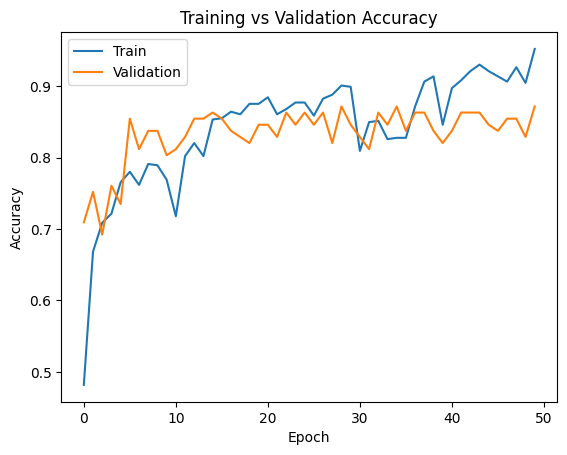

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test,y_test)
print("VGG16 Test Accuracy:", test_acc)
print("VGG16 Test Loss:", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.8220 - loss: 0.9893
VGG16 Test Accuracy: 0.8220338821411133
VGG16 Test Loss: 0.9892712831497192


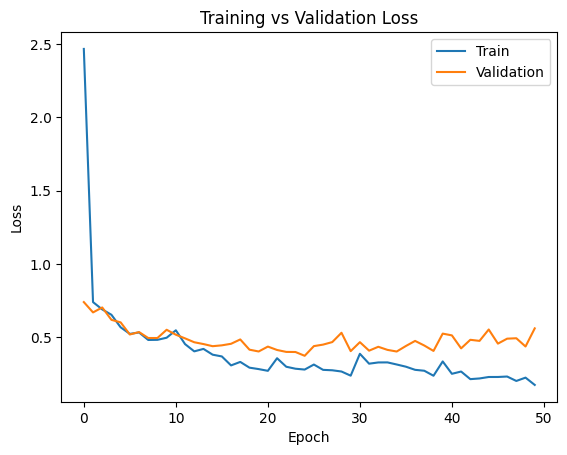

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred,axis=1)
y_true = np.argmax(y_test,axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step


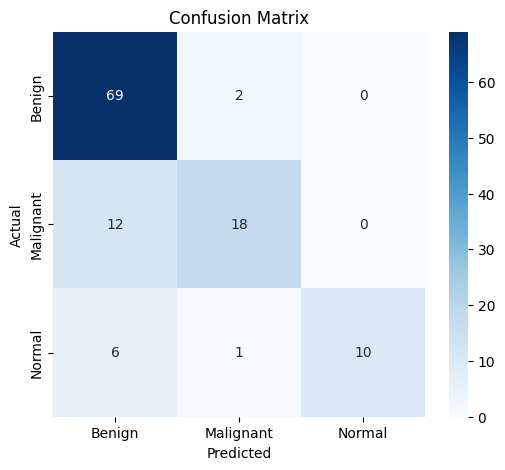

In [ ]:
cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant","Normal"],
    yticklabels=["Benign","Malignant","Normal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=["Benign","Malignant","Normal"]
))

              precision    recall  f1-score   support

      Benign       0.79      0.97      0.87        71
   Malignant       0.86      0.60      0.71        30
      Normal       1.00      0.59      0.74        17

    accuracy                           0.82       118
   macro avg       0.88      0.72      0.77       118
weighted avg       0.84      0.82      0.81       118



In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/drive/MyDrive/vgg16_best.h5")

loss, acc = best_model.evaluate(X_test,y_test)

print("Best VGG16 Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 344ms/step - accuracy: 0.8475 - loss: 0.6086
Best VGG16 Test Accuracy: 0.8474576473236084


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SeparableConv2D, MaxPooling2D, Flatten, Dense, Dropout

dsc_model = Sequential()

dsc_model.add(SeparableConv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
dsc_model.add(MaxPooling2D(2,2))

dsc_model.add(SeparableConv2D(64,(3,3),activation='relu'))
dsc_model.add(MaxPooling2D(2,2))

dsc_model.add(SeparableConv2D(128,(3,3),activation='relu'))
dsc_model.add(MaxPooling2D(2,2))

dsc_model.add(Flatten())
dsc_model.add(Dense(128,activation='relu'))
dsc_model.add(Dropout(0.5))

dsc_model.add(Dense(3,activation='softmax'))

dsc_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dsc_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_separable_conv.py:104: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 222, 222, 32)   │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 109, 109, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 52, 52, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,087,550 (42.30 MB)

 Trainable params: 11,087,550 (42.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# best_ckpt_dsc = ModelCheckpoint(
#     "/content/drive/MyDrive/dsc_best.h5",
#     monitor="val_accuracy",
#     save_best_only=True,
#     mode="max"
# )

# backup_ckpt_dsc = ModelCheckpoint(
#     "/content/drive/MyDrive/dsc_backup.keras",
#     save_best_only=False
# )

# logger_dsc = CSVLogger("/content/drive/MyDrive/dsc_log.csv", append=True)

# history_dsc = dsc_model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val,y_val),
#     epochs=50,
#     batch_size=16,
#     callbacks=[best_ckpt_dsc, backup_ckpt_dsc, logger_dsc]
# )

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.5750 - loss: 1.0459

35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - accuracy: 0.5476 - loss: 1.0355 - val_accuracy: 0.5812 - val_loss: 0.9862
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.5476 - loss: 0.9970 - val_accuracy: 0.5812 - val_loss: 0.9517
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5476 - loss: 1.0096 - val_accuracy: 0.5812 - val_loss: 0.9908
Epoch 4/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5622 - loss: 0.9831

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy: 0.5531 - loss: 0.9734 - val_accuracy: 0.6325 - val_loss: 0.9583
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.6136 - loss: 0.8575 - val_accuracy: 0.6068 - val_loss: 0.8836
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6392 - loss: 0.7992 - val_accuracy: 0.6239 - val_loss: 0.8012
Epoch 7/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6741 - loss: 0.7614

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6722 - loss: 0.7476 - val_accuracy: 0.6923 - val_loss: 0.7627
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.6996 - loss: 0.6835 - val_accuracy: 0.6581 - val_loss: 0.7967
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.7289 - loss: 0.5882 - val_accuracy: 0.6667 - val_loss: 0.7880
Epoch 10/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7729 - loss: 0.5267 - val_accuracy: 0.6667 - val_loss: 0.7290
Epoch 11/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8218 - loss: 0.4516

35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 332ms/step - accuracy: 0.7985 - loss: 0.4900 - val_accuracy: 0.7265 - val_loss: 0.7537
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8462 - loss: 0.3892 - val_accuracy: 0.6838 - val_loss: 0.7906
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8736 - loss: 0.3410 - val_accuracy: 0.6923 - val_loss: 0.8997
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.9029 - loss: 0.3000 - val_accuracy: 0.7265 - val_loss: 0.9771
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.9048 - loss: 0.2381 - val_accuracy: 0.7179 - val_loss: 1.0402
Epoch 16/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.9396 - loss: 0.1794 - val_accuracy: 0.7009 - val_loss: 1.1715
Epoch 17/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9451 - loss: 0.1604 - val_accuracy: 0.7179 - val_loss: 1.1180
Epoch 18/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.9377 - loss: 0.1386 - val_accuracy: 0.7094 -

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9542 - loss: 0.1227 - val_accuracy: 0.7350 - val_loss: 1.3059
Epoch 20/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9524 - loss: 0.1525 - val_accuracy: 0.7265 - val_loss: 1.3328
Epoch 21/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9670 - loss: 0.0917 - val_accuracy: 0.6667 - val_loss: 1.3574
Epoch 22/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step - accuracy: 0.9707 - loss: 0.0736 - val_accuracy: 0.7094 - val_loss: 1.7209
Epoch 23/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - accuracy: 0.9799 - loss: 0.0662 - val_accuracy: 0.7350 - val_loss: 1.7579
Epoch 24/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.9670 - loss: 0.0930 - val_accuracy: 0.7009 - val_loss: 1.5468
Epoch 25/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9707 - loss: 0.0867 - val_accuracy: 0.7009 - val_loss: 1.5681
Epoch 26/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9761 - loss: 0.1437

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step - accuracy: 0.9780 - loss: 0.0924 - val_accuracy: 0.7436 - val_loss: 1.6661
Epoch 27/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9689 - loss: 0.1128 - val_accuracy: 0.7179 - val_loss: 1.7852
Epoch 28/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.9744 - loss: 0.0671 - val_accuracy: 0.6923 - val_loss: 1.8276
Epoch 29/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.9817 - loss: 0.0650 - val_accuracy: 0.7179 - val_loss: 1.7967
Epoch 30/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 164ms/step - accuracy: 0.9835 - loss: 0.0708 - val_accuracy: 0.7094 - val_loss: 1.9276
Epoch 31/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.9744 - loss: 0.0653 - val_accuracy: 0.7094 - val_loss: 1.9788
Epoch 32/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9762 - loss: 0.0664 - val_accuracy: 0.7094 - val_loss: 1.7524
Epoch 33/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.9835 - loss: 0.0455 - val_accuracy: 0.7350 - v

In [ ]:
dsc_model = load_model("/content/drive/MyDrive/dsc_backup.keras")

log = pd.read_csv("/content/drive/MyDrive/dsc_log.csv")
last_epoch = len(log)

print("Resuming DSC from:", last_epoch)

history_dsc = dsc_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    initial_epoch=last_epoch,
    batch_size=16,
    callbacks=[best_ckpt_dsc, backup_ckpt_dsc, logger_dsc]
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 15 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Resuming DSC from: 50
Epoch 51/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 286ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.7009 - val_loss: 3.1130
Epoch 52/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9908 - loss: 0.0264 - val_accuracy: 0.7179 - val_loss: 3.1778
Epoch 53/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9927 - loss: 0.0283 - val_accuracy: 0.7265 - val_loss: 3.1736
Epoch 54/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9945 - loss: 0.0203 - val_accuracy: 0.7179 - val_loss: 3.3860
Epoch 55/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9927 - loss: 0.0162 - val_accuracy: 0.7179 - val_loss: 3.5726
Epoch 56/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.9890 - loss: 0.0419 - val_accuracy: 0.7179 - val_loss: 3.4062
Epoch 57/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9945 - loss: 0.0323 - val_accuracy: 0.7179 - val_loss: 3.3750
Epoch 58/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9890 -

In [ ]:
print("DSC Train Acc:", history_dsc.history['accuracy'][-1])
print("DSC Val Acc:", history_dsc.history['val_accuracy'][-1])

DSC Train Acc: 0.9945054650306702
DSC Val Acc: 0.7179487347602844


In [ ]:
test_loss_dsc, test_acc_dsc = dsc_model.evaluate(X_test,y_test)
print("DSC Test Accuracy:", test_acc_dsc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6780 - loss: 3.3609
DSC Test Accuracy: 0.6779661178588867


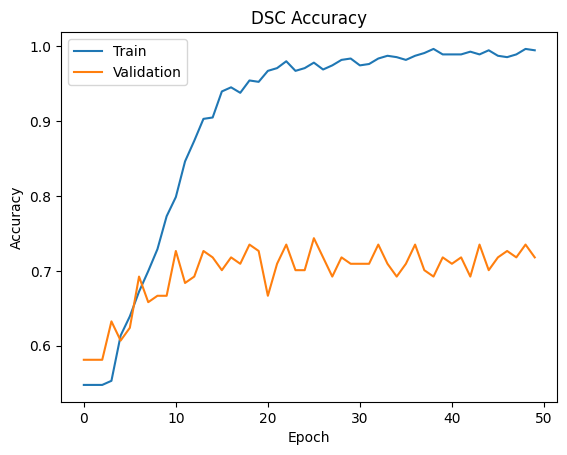

In [ ]:
plt.plot(history_dsc.history['accuracy'])
plt.plot(history_dsc.history['val_accuracy'])

plt.title("DSC Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
best_dsc = load_model("/content/drive/MyDrive/dsc_best.h5")

loss, acc = best_dsc.evaluate(X_test,y_test)

print("Best DSC Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step - accuracy: 0.6949 - loss: 2.0338
Best DSC Accuracy: 0.694915235042572


In [ ]:
test_loss_dsc, test_acc_dsc = dsc_model.evaluate(X_test,y_test)

print("DSC Test Accuracy:", test_acc_dsc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6780 - loss: 3.3609
DSC Test Accuracy: 0.6779661178588867


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_mob = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_mob.layers:
    layer.trainable = False

x = base_mob.output
x = GlobalAveragePooling2D()(x)

x = Dense(128,activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(3,activation='softmax')(x)

mobilenet_model = Model(inputs=base_mob.input, outputs=output)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,360,451 (12.82 MB)

 Trainable params: 131,587 (514.01 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [ ]:
# best_ckpt_mob = ModelCheckpoint(
#     "/content/drive/MyDrive/mob_best.h5",
#     monitor="val_accuracy",
#     save_best_only=True,
#     mode="max"
# )

# backup_ckpt_mob = ModelCheckpoint(
#     "/content/drive/MyDrive/mob_backup.keras",
#     save_best_only=False
# )

# logger_mob = CSVLogger("/content/drive/MyDrive/mob_log.csv", append=True)

# history_mob = mobilenet_model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val,y_val),
#     epochs=50,
#     batch_size=16,
#     callbacks=[best_ckpt_mob, backup_ckpt_mob, logger_mob]
# )

Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.5615 - loss: 1.1576

35/35 ━━━━━━━━━━━━━━━━━━━━ 40s 756ms/step - accuracy: 0.5824 - loss: 1.0245 - val_accuracy: 0.7179 - val_loss: 0.6322
Epoch 2/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7313 - loss: 0.6169

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7436 - loss: 0.6407 - val_accuracy: 0.7607 - val_loss: 0.5804
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7839 - loss: 0.5351 - val_accuracy: 0.7436 - val_loss: 0.5468
Epoch 4/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8441 - loss: 0.4381

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8187 - loss: 0.4604 - val_accuracy: 0.7949 - val_loss: 0.4986
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8260 - loss: 0.4389 - val_accuracy: 0.7949 - val_loss: 0.4964
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8095 - loss: 0.4452 - val_accuracy: 0.7778 - val_loss: 0.4648
Epoch 7/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8619 - loss: 0.3183

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8425 - loss: 0.3600 - val_accuracy: 0.8034 - val_loss: 0.4304
Epoch 8/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8843 - loss: 0.3194

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8810 - loss: 0.3338 - val_accuracy: 0.8205 - val_loss: 0.4095
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8846 - loss: 0.2902 - val_accuracy: 0.8205 - val_loss: 0.4067
Epoch 10/50
32/35 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9126 - loss: 0.2788

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9231 - loss: 0.2649 - val_accuracy: 0.8291 - val_loss: 0.3729
Epoch 11/50
33/35 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9144 - loss: 0.2157

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9121 - loss: 0.2452 - val_accuracy: 0.8462 - val_loss: 0.3883
Epoch 12/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9231 - loss: 0.2550 - val_accuracy: 0.8376 - val_loss: 0.4089
Epoch 13/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9396 - loss: 0.2021 - val_accuracy: 0.8291 - val_loss: 0.4260
Epoch 14/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9286 - loss: 0.1959 - val_accuracy: 0.8205 - val_loss: 0.4079
Epoch 15/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9377 - loss: 0.1895 - val_accuracy: 0.8205 - val_loss: 0.3698
Epoch 16/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9560 - loss: 0.1558 - val_accuracy: 0.8205 - val_loss: 0.3753
Epoch 17/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9451 - loss: 0.1598 - val_accuracy: 0.8291 - val_loss: 0.3364
Epoch 18/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9615 - loss: 0.1205 - val_accuracy: 0.8376 - val_l

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9725 - loss: 0.1073 - val_accuracy: 0.8632 - val_loss: 0.3179
Epoch 22/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9744 - loss: 0.0945 - val_accuracy: 0.8291 - val_loss: 0.3194
Epoch 23/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9799 - loss: 0.0830 - val_accuracy: 0.8547 - val_loss: 0.3519
Epoch 24/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9872 - loss: 0.0730 - val_accuracy: 0.8376 - val_loss: 0.3380
Epoch 25/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9762 - loss: 0.0843 - val_accuracy: 0.8547 - val_loss: 0.3434
Epoch 26/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9799 - loss: 0.0793 - val_accuracy: 0.8547 - val_loss: 0.3584
Epoch 27/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9835 - loss: 0.0663 - val_accuracy: 0.8462 - val_loss: 0.3649
Epoch 28/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9853 - loss: 0.0657 - val_accuracy: 0.8632 - val_l

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9835 - loss: 0.0663 - val_accuracy: 0.8803 - val_loss: 0.3758
Epoch 31/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9872 - loss: 0.0542 - val_accuracy: 0.8547 - val_loss: 0.3765
Epoch 32/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9872 - loss: 0.0519 - val_accuracy: 0.8462 - val_loss: 0.3751
Epoch 33/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9908 - loss: 0.0549 - val_accuracy: 0.8462 - val_loss: 0.3735
Epoch 34/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9780 - loss: 0.0663 - val_accuracy: 0.8547 - val_loss: 0.3478
Epoch 35/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9908 - loss: 0.0483 - val_accuracy: 0.8547 - val_loss: 0.3873
Epoch 36/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9853 - loss: 0.0471 - val_accuracy: 0.8462 - val_loss: 0.3632
Epoch 37/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9927 - loss: 0.0373 - val_accuracy: 0.8462 - val_l

In [ ]:
mobilenet_model = load_model("/content/drive/MyDrive/mob_backup.keras")

log = pd.read_csv("/content/drive/MyDrive/mob_log.csv")
last_epoch = len(log)

print("Resuming MobileNet from:", last_epoch)

history_mob = mobilenet_model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=100,
    initial_epoch=last_epoch,
    batch_size=16,
    callbacks=[best_ckpt_mob, backup_ckpt_mob, logger_mob]
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Resuming MobileNet from: 50
Epoch 51/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 365ms/step - accuracy: 0.9817 - loss: 0.0562 - val_accuracy: 0.8547 - val_loss: 0.4702
Epoch 52/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9799 - loss: 0.0347 - val_accuracy: 0.8462 - val_loss: 0.5110
Epoch 53/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9927 - loss: 0.0307 - val_accuracy: 0.8376 - val_loss: 0.4927
Epoch 54/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9853 - loss: 0.0363 - val_accuracy: 0.8291 - val_loss: 0.5093
Epoch 55/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9890 - loss: 0.0388 - val_accuracy: 0.8547 - val_loss: 0.4404
Epoch 56/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9927 - loss: 0.0301 - val_accuracy: 0.8632 - val_loss: 0.4407
Epoch 57/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9890 - loss: 0.0370 - val_accuracy: 0.8632 - val_loss: 0.5596
Epoch 58/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.

In [ ]:
print("MobileNet Train Acc:", history_mob.history['accuracy'][-1])
print("MobileNet Val Acc:", history_mob.history['val_accuracy'][-1])

MobileNet Train Acc: 0.9963369965553284
MobileNet Val Acc: 0.8547008633613586


In [ ]:
test_loss_mob, test_acc_mob = mobilenet_model.evaluate(X_test,y_test)
print("MobileNet Test Accuracy:", test_acc_mob)

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8559 - loss: 0.4643
MobileNet Test Accuracy: 0.8559321761131287


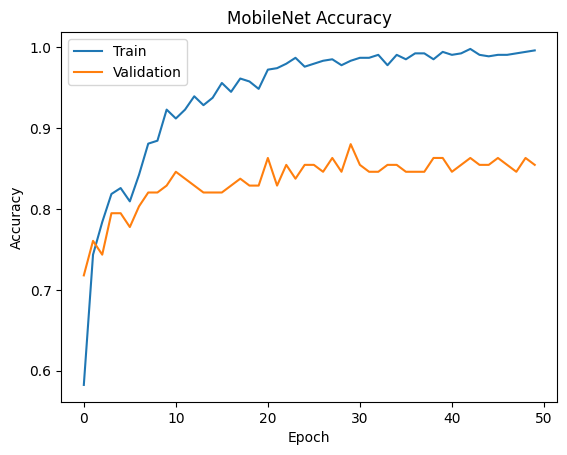

In [ ]:
plt.plot(history_mob.history['accuracy'])
plt.plot(history_mob.history['val_accuracy'])

plt.title("MobileNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

In [ ]:
best_mob = load_model("/content/drive/MyDrive/mob_best.h5")

loss, acc = best_mob.evaluate(X_test,y_test)

print("Best MobileNet Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 728ms/step - accuracy: 0.8729 - loss: 0.3741
Best MobileNet Accuracy: 0.8728813529014587


In [ ]:
print("\nMODEL PARAMETERS")

print("VGG16 Params:", model.count_params())
print("DSC Params:", dsc_model.count_params())
print("MobileNet Params:", mobilenet_model.count_params())


MODEL PARAMETERS
VGG16 Params: 21138243
DSC Params: 11087550
MobileNet Params: 3360451


In [ ]:

# print("\nMODEL ACCURACY")

# print("VGG16 Accuracy:", test_acc)
# print("DSC Accuracy:", test_acc_dsc)
# print("MobileNet Accuracy:", test_acc_mob)


MODEL ACCURACY
VGG16 Accuracy: 0.8220338821411133
DSC Accuracy: 0.6779661178588867
MobileNet Accuracy: 0.8559321761131287


In [ ]:
print("VGG16 Training Accuracy:", history.history['accuracy'][-1])
print("VGG16 with DSC Train Acc:", history_dsc.history['accuracy'][-1])
print("MobileNet Train Acc:", history_mob.history['accuracy'][-1])


VGG16 Training Accuracy: 0.9358974099159241
VGG16 with DSC Train Acc: 0.9963369965553284
MobileNet Train Acc: 0.9963369965553284
